In [1]:
import argparse
import logging
import os
from functools import partial
from multiprocessing import Pool
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import polars as pl
from scipy.signal import stft
from scipy.stats import kurtosis, skew
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
path = "../silver_data/silver_layer_redo_by_trial.parquet"

In [3]:
Path(path).exists()

True

In [4]:
df = pl.read_parquet(path)

In [5]:
df.head()

SpindleAccX_mean,SpindleAccX_std,SpindleAccX_rms,SpindleAccX_kurtosis,SpindleAccX_skewness,SpindleAccX_peak_to_peak,SpindleAccX_crest_factor,SpindleAccX_shape_factor,SpindleAccX_impulse_factor,SpindleAccX_margin_factor,SpindleAccX_energy,SpindleAccX_spectral_kurtosis_mean,SpindleAccX_spectral_kurtosis_std,SpindleAccX_spectral_kurtosis_skewness,SpindleAccX_spectral_kurtosis_kurtosis,SpindleAccY_mean,SpindleAccY_std,SpindleAccY_rms,SpindleAccY_kurtosis,SpindleAccY_skewness,SpindleAccY_peak_to_peak,SpindleAccY_crest_factor,SpindleAccY_shape_factor,SpindleAccY_impulse_factor,SpindleAccY_margin_factor,SpindleAccY_energy,SpindleAccY_spectral_kurtosis_mean,SpindleAccY_spectral_kurtosis_std,SpindleAccY_spectral_kurtosis_skewness,SpindleAccY_spectral_kurtosis_kurtosis,SpindleAccZ_mean,SpindleAccZ_std,SpindleAccZ_rms,SpindleAccZ_kurtosis,SpindleAccZ_skewness,SpindleAccZ_peak_to_peak,SpindleAccZ_crest_factor,…,PlateLFAccY_spectral_kurtosis_std,PlateLFAccY_spectral_kurtosis_skewness,PlateLFAccY_spectral_kurtosis_kurtosis,PlateLFAccZ_mean,PlateLFAccZ_std,PlateLFAccZ_rms,PlateLFAccZ_kurtosis,PlateLFAccZ_skewness,PlateLFAccZ_peak_to_peak,PlateLFAccZ_crest_factor,PlateLFAccZ_shape_factor,PlateLFAccZ_impulse_factor,PlateLFAccZ_margin_factor,PlateLFAccZ_energy,PlateLFAccZ_spectral_kurtosis_mean,PlateLFAccZ_spectral_kurtosis_std,PlateLFAccZ_spectral_kurtosis_skewness,PlateLFAccZ_spectral_kurtosis_kurtosis,Power_mean,Power_std,Power_rms,Power_kurtosis,Power_skewness,Power_peak_to_peak,Power_crest_factor,Power_shape_factor,Power_impulse_factor,Power_margin_factor,Power_energy,Power_spectral_kurtosis_mean,Power_spectral_kurtosis_std,Power_spectral_kurtosis_skewness,Power_spectral_kurtosis_kurtosis,trial,run,fault_mode,routine
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,str,str
0.019752,0.206723,0.207664,-0.312824,0.122067,1.307372,3.393427,1.252205,4.249267,5.063296,3365.466516,8.696128,9.694585,0.71804,-0.636728,0.010036,0.225123,0.225347,-1.410174,0.153377,0.85164,2.063564,1.124763,2.321021,2.567968,3963.018345,9.251799,10.122414,0.710592,-0.893148,0.030439,0.099986,0.104517,-0.141843,0.037173,0.630471,3.206507,…,20.802444,-0.443653,-1.627064,-0.01152,0.23942,0.239697,-0.797423,-0.206522,1.049743,2.537162,1.20694,3.062203,3.567233,4483.816033,36.530962,14.692319,-1.349478,0.526746,0.79962,0.099491,0.805785,31.069589,-5.489208,0.746922,1.068323,1.007711,1.076561,1.08396,50671.227728,39.613993,8.106514,-1.777528,2.665865,"""Segmented_Machining_ToolWear""",1,"""ToolWear""","""Machining"""
0.021272,0.216735,0.217776,-0.602858,-0.175649,1.170031,2.892632,1.211072,3.503187,4.072747,3701.213143,7.692665,9.892391,1.089134,-0.016027,0.012164,0.294465,0.294716,-1.100682,0.348456,1.150206,2.105033,1.159688,2.441181,2.738575,6778.455586,12.744369,9.548594,-0.093261,-1.490754,0.031441,0.103433,0.108107,-0.165041,0.028762,0.733795,3.75872,…,9.999042,-0.723932,-1.215435,-0.01149,0.274309,0.27455,-1.009668,-0.152309,1.381578,2.569666,1.174549,3.018199,3.426909,5882.540159,19.419409,6.627822,-1.915495,2.592652,0.730535,0.077638,0.734649,38.769527,-5.994966,0.668027,1.067458,1.005631,1.073469,1.078576,42119.413328,35.681694,9.261252,-1.490995,1.359287,"""Segmented_Machining_ToolWear""",2,"""ToolWear""","""Machining"""
0.020867,0.215656,0.216663,-0.562219,-0.217419,1.173007,2.751777,1.215103,3.343694,3.899674,3663.46722,9.923054,12.724082,1.163288,0.188719,0.011811,0.285277,0.285522,-1.084603,0.360825,1.081681,2.088319,1.161179,2.424912,2.722994,6362.114984,11.676748,9.111624,0.031077,-1.409195,0.030818,0.101451,0.106029,-0.170462,0.014882,0.668287,3.470477,…,9.8076,-0.558274,-1.450383,-0.011457,0.277168,0.277405,-1.001278,-0.14153,1.349343,2.438541,1.174367,2.863741,3.25051,6005.520991,19.284345,6.625271,-1.892083,2.502101

In [17]:
df

SpindleAccX_mean,SpindleAccX_std,SpindleAccX_rms,SpindleAccX_kurtosis,SpindleAccX_skewness,SpindleAccX_peak_to_peak,SpindleAccX_crest_factor,SpindleAccX_shape_factor,SpindleAccX_impulse_factor,SpindleAccX_margin_factor,SpindleAccX_energy,SpindleAccX_spectral_kurtosis_mean,SpindleAccX_spectral_kurtosis_std,SpindleAccX_spectral_kurtosis_skewness,SpindleAccX_spectral_kurtosis_kurtosis,SpindleAccY_mean,SpindleAccY_std,SpindleAccY_rms,SpindleAccY_kurtosis,SpindleAccY_skewness,SpindleAccY_peak_to_peak,SpindleAccY_crest_factor,SpindleAccY_shape_factor,SpindleAccY_impulse_factor,SpindleAccY_margin_factor,SpindleAccY_energy,SpindleAccY_spectral_kurtosis_mean,SpindleAccY_spectral_kurtosis_std,SpindleAccY_spectral_kurtosis_skewness,SpindleAccY_spectral_kurtosis_kurtosis,SpindleAccZ_mean,SpindleAccZ_std,SpindleAccZ_rms,SpindleAccZ_kurtosis,SpindleAccZ_skewness,SpindleAccZ_peak_to_peak,SpindleAccZ_crest_factor,…,PlateLFAccY_spectral_kurtosis_std,PlateLFAccY_spectral_kurtosis_skewness,PlateLFAccY_spectral_kurtosis_kurtosis,PlateLFAccZ_mean,PlateLFAccZ_std,PlateLFAccZ_rms,PlateLFAccZ_kurtosis,PlateLFAccZ_skewness,PlateLFAccZ_peak_to_peak,PlateLFAccZ_crest_factor,PlateLFAccZ_shape_factor,PlateLFAccZ_impulse_factor,PlateLFAccZ_margin_factor,PlateLFAccZ_energy,PlateLFAccZ_spectral_kurtosis_mean,PlateLFAccZ_spectral_kurtosis_std,PlateLFAccZ_spectral_kurtosis_skewness,PlateLFAccZ_spectral_kurtosis_kurtosis,Power_mean,Power_std,Power_rms,Power_kurtosis,Power_skewness,Power_peak_to_peak,Power_crest_factor,Power_shape_factor,Power_impulse_factor,Power_margin_factor,Power_energy,Power_spectral_kurtosis_mean,Power_spectral_kurtosis_std,Power_spectral_kurtosis_skewness,Power_spectral_kurtosis_kurtosis,trial,run,fault_mode,routine
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,str,str
0.019752,0.206723,0.207664,-0.312824,0.122067,1.307372,3.393427,1.252205,4.249267,5.063296,3365.466516,8.696128,9.694585,0.71804,-0.636728,0.010036,0.225123,0.225347,-1.410174,0.153377,0.85164,2.063564,1.124763,2.321021,2.567968,3963.018345,9.251799,10.122414,0.710592,-0.893148,0.030439,0.099986,0.104517,-0.141843,0.037173,0.630471,3.206507,…,20.802444,-0.443653,-1.627064,-0.01152,0.23942,0.239697,-0.797423,-0.206522,1.049743,2.537162,1.20694,3.062203,3.567233,4483.816033,36.530962,14.692319,-1.349478,0.526746,0.79962,0.099491,0.805785,31.069589,-5.489208,0.746922,1.068323,1.007711,1.076561,1.08396,50671.227728,39.613993,8.106514,-1.777528,2.665865,"""Segmented_Machining_ToolWear""",1,"""ToolWear""","""Machining"""
0.021272,0.216735,0.217776,-0.602858,-0.175649,1.170031,2.892632,1.211072,3.503187,4.072747,3701.213143,7.692665,9.892391,1.089134,-0.016027,0.012164,0.294465,0.294716,-1.100682,0.348456,1.150206,2.105033,1.159688,2.441181,2.738575,6778.455586,12.744369,9.548594,-0.093261,-1.490754,0.031441,0.103433,0.108107,-0.165041,0.028762,0.733795,3.75872,…,9.999042,-0.723932,-1.215435,-0.01149,0.274309,0.27455,-1.009668,-0.152309,1.381578,2.569666,1.174549,3.018199,3.426909,5882.540159,19.419409,6.627822,-1.915495,2.592652,0.730535,0.077638,0.734649,38.769527,-5.994966,0.668027,1.067458,1.005631,1.073469,1.078576,42119.413328,35.681694,9.261252,-1.490995,1.359287,"""Segmented_Machining_ToolWear""",2,"""ToolWear""","""Machining"""
0.020867,0.215656,0.216663,-0.562219,-0.217419,1.173007,2.751777,1.215103,3.343694,3.899674,3663.46722,9.923054,12.724082,1.163288,0.188719,0.011811,0.285277,0.285522,-1.084603,0.360825,1.081681,2.088319,1.161179,2.424912,2.722994,6362.114984,11.676748,9.111624,0.031077,-1.409195,0.030818,0.101451,0.106029,-0.170462,0.014882,0.668287,3.470477,…,9.8076,-0.558274,-1.450383,-0.011457,0.277168,0.277405,-1.001278,-0.14153,1.349343,2.438541,1.174367,2.863741,3.25051,6005.520991,19.284345,6.625271,-1.892083,2.502101

In [6]:
bad_cols = [
    c for c in df.columns
    if df[c].null_count() > 0
    or (df[c].dtype in (pl.Float32, pl.Float64) and df[c].is_nan().any())
]
print(bad_cols)
# df = df.drop(bad_cols)

[]


Machining [0.19931847 0.09757894 0.077004  ]


/tmp/ipykernel_304167/4065383846.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(modes))


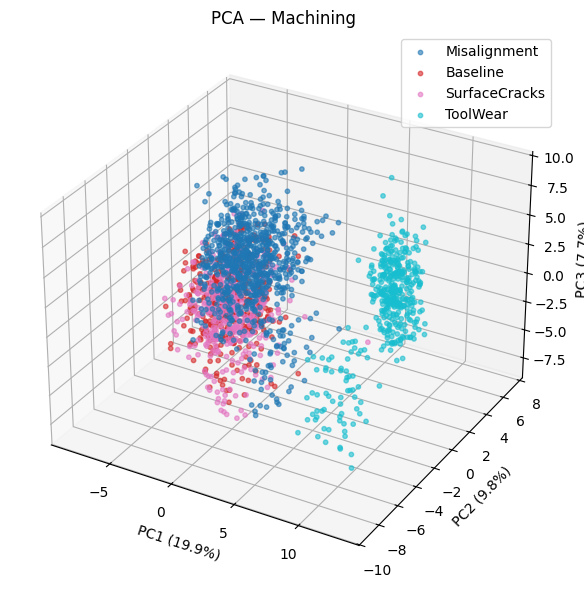

Spindle12000 [0.31589107 0.16704801 0.09825947]


/tmp/ipykernel_304167/4065383846.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(modes))


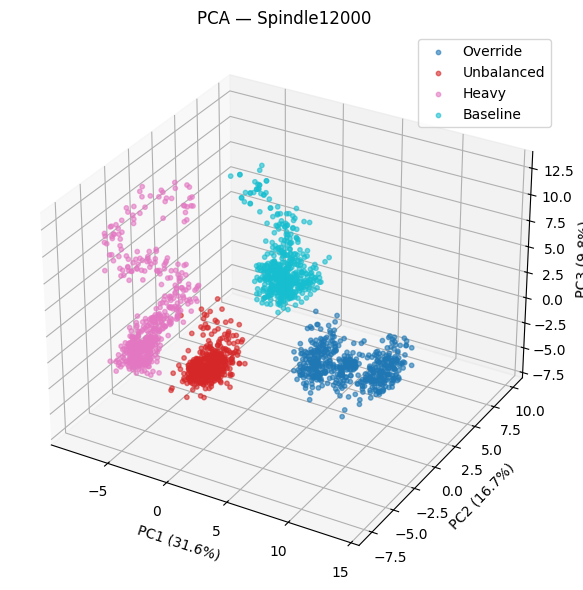

Spindle5000 [0.4937931  0.07293446 0.05317245]


/tmp/ipykernel_304167/4065383846.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(modes))


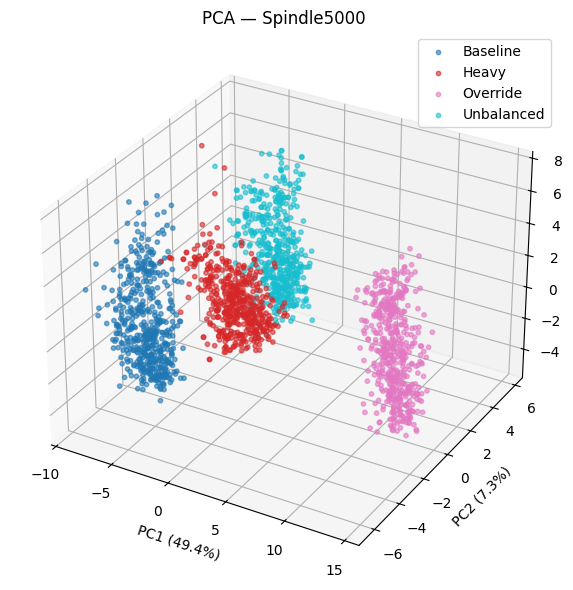

Linear [0.34373663 0.1122322  0.08452496]


/tmp/ipykernel_304167/4065383846.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(modes))


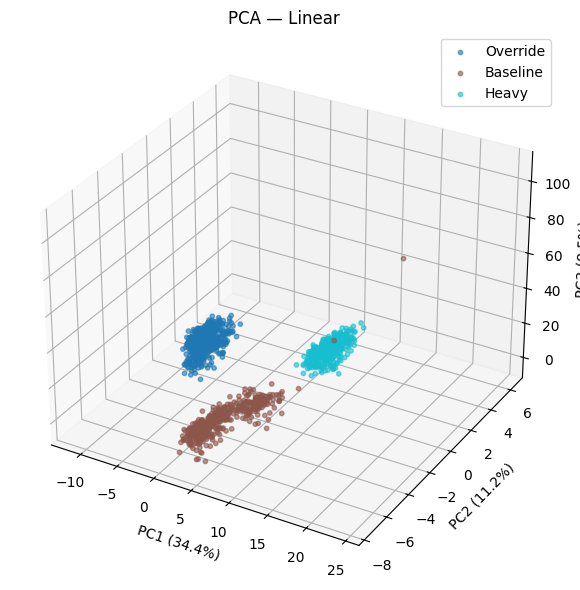

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm

exclude_cols = ["trial", "run", "fault_mode", "routine"]
feature_cols = [c for c in df.columns if c not in exclude_cols]

for routine in df["routine"].unique().to_list():
    sub_df = df.filter(pl.col("routine") == routine)

    X = sub_df.select(feature_cols).to_numpy()
    X_scaled = StandardScaler().fit_transform(X)

    pca = PCA(n_components=3)
    components = pca.fit_transform(X_scaled)

    pca_df = sub_df.select(["trial", "run", "fault_mode"]).with_columns([
        pl.Series("PC1", components[:, 0]),
        pl.Series("PC2", components[:, 1]),
        pl.Series("PC3", components[:, 2]),
    ])

    print(routine, pca.explained_variance_ratio_)

    modes = pca_df["fault_mode"].unique().to_list()
    cmap = cm.get_cmap("tab10", len(modes))
    color_map = {m: cmap(i) for i, m in enumerate(modes)}

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    for m in modes:
        s = pca_df.filter(pl.col("fault_mode") == m)
        ax.scatter(s["PC1"], s["PC2"], s["PC3"], label=m, color=color_map[m], alpha=0.6, s=10)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
    ax.legend()
    plt.title(f"PCA — {routine}")
    plt.tight_layout()
    plt.show()

              precision    recall  f1-score   support

    Baseline       1.00      1.00      1.00       175
       Heavy       1.00      1.00      1.00       175
    Override       1.00      1.00      1.00       175

    accuracy                           1.00       525
   macro avg       1.00      1.00      1.00       525
weighted avg       1.00      1.00      1.00       525



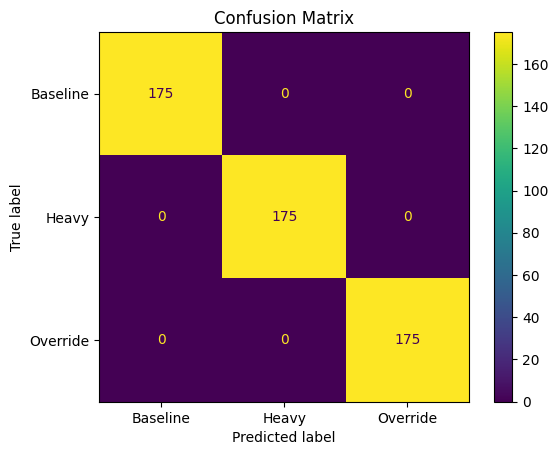

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X = pca_df.select(["PC1", "PC2", "PC3"]).to_numpy()
y = pca_df["fault_mode"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, stratify=y, random_state=42
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

=== Logistic Regression ===
               precision    recall  f1-score   support

     Baseline       1.00      1.00      1.00       147
 Misalignment       1.00      1.00      1.00       292
SurfaceCracks       1.00      1.00      1.00       147
     ToolWear       1.00      1.00      1.00       147

     accuracy                           1.00       733
    macro avg       1.00      1.00      1.00       733
 weighted avg       1.00      1.00      1.00       733

=== XGBoost ===
               precision    recall  f1-score   support

     Baseline       1.00      1.00      1.00       147
 Misalignment       1.00      1.00      1.00       292
SurfaceCracks       1.00      1.00      1.00       147
     ToolWear       1.00      0.99      1.00       147

     accuracy                           1.00       733
    macro avg       1.00      1.00      1.00       733
 weighted avg       1.00      1.00      1.00       733



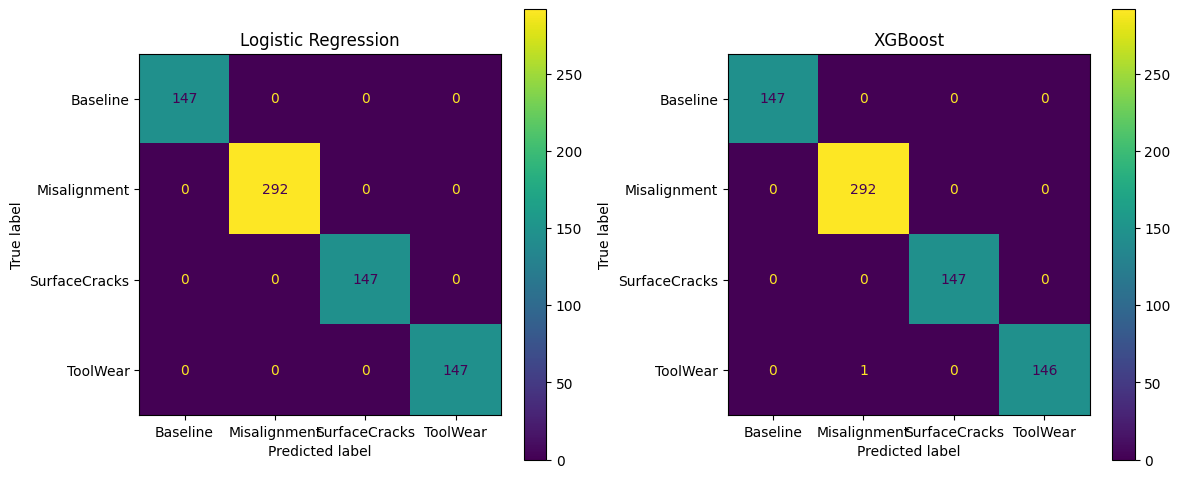

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
import matplotlib.pyplot as plt

exclude_cols = ["trial", "run", "fault_mode", "routine"]
feature_cols = [c for c in df.columns if c not in exclude_cols]

sub_df = df.filter(pl.col("routine") == "Machining")  # adjust routine as needed

X = sub_df.select(feature_cols).to_numpy()
y = sub_df["fault_mode"].to_numpy()

X_scaled = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.35, stratify=y, random_state=42
)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# --- Logistic Regression ---
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

# --- XGBoost ---
xgb_clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    eval_metric="mlogloss", random_state=42
)
xgb_clf.fit(X_train, y_train_enc)
y_pred_xgb_enc = xgb_clf.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)
print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))

# --- Confusion matrices side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr), display_labels=lr.classes_).plot(ax=axes[0])
axes[0].set_title("Logistic Regression")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb), display_labels=le.classes_).plot(ax=axes[1])
axes[1].set_title("XGBoost")
plt.tight_layout()
plt.show()

In [12]:
import numpy as np

exclude_cols = ["trial", "run", "fault_mode", "routine"]
feature_cols = [c for c in sub_df.columns if c not in exclude_cols]

within_std = (
    sub_df.group_by("fault_mode")
    .agg([pl.col(c).std().alias(c) for c in feature_cols])
)

between_std = sub_df.group_by("fault_mode").agg(
    [pl.col(c).mean().alias(c) for c in feature_cols]
).select(feature_cols).to_numpy().std(axis=0)

within_avg = within_std.select(feature_cols).to_numpy().mean(axis=0)

ratio = within_avg / between_std
print("mean within/between ratio:", ratio.mean())

sub = sub_df.filter(pl.col("fault_mode") == "Baseline").select(feature_cols).to_numpy()
corr = np.corrcoef(sub)
print("mean pairwise correlation within Baseline runs:", corr[np.triu_indices_from(corr, k=1)].mean())

mean within/between ratio: 3.592428796242126
mean pairwise correlation within Baseline runs: 0.9877475260130083


In [13]:
cross = sub_df.filter(pl.col("fault_mode") == "Baseline").select(feature_cols).to_numpy()
other = sub_df.filter(pl.col("fault_mode") == "Misalignment").select(feature_cols).to_numpy()

# average correlation between a Baseline row and a Misalignment row
n = min(len(cross), len(other))
cross_corr = np.corrcoef(cross[:n], other[:n])[:n, n:]
print("mean cross-class correlation:", cross_corr.mean())

mean cross-class correlation: 0.984358384247789


In [15]:
print(sub_df.group_by("fault_mode").agg(pl.col("trial").n_unique().alias("n_trial_files")))

shape: (4, 2)
┌───────────────┬───────────────┐
│ fault_mode    ┆ n_trial_files │
│ ---           ┆ ---           │
│ str           ┆ u32           │
╞═══════════════╪═══════════════╡
│ Baseline      ┆ 1             │
│ SurfaceCracks ┆ 1             │
│ ToolWear      ┆ 1             │
│ Misalignment  ┆ 1             │
└───────────────┴───────────────┘


In [16]:
frames_train, frames_test = [], []

for mode in sub_df["fault_mode"].unique().to_list():
    mode_df = sub_df.filter(pl.col("fault_mode") == mode).sort("run")
    n = mode_df.height
    split_idx = int(n * 0.65)
    frames_train.append(mode_df[:split_idx])
    frames_test.append(mode_df[split_idx:])

train_df = pl.concat(frames_train)
test_df = pl.concat(frames_test)

X_train = StandardScaler().fit(train_df.select(feature_cols).to_numpy())
scaler = StandardScaler().fit(train_df.select(feature_cols).to_numpy())
X_train = scaler.transform(train_df.select(feature_cols).to_numpy())
X_test = scaler.transform(test_df.select(feature_cols).to_numpy())
y_train = train_df["fault_mode"].to_numpy()
y_test = test_df["fault_mode"].to_numpy()

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("=== Logistic Regression (time-based split) ===")
print(classification_report(y_test, y_pred_lr))

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    eval_metric="mlogloss", random_state=42
)
xgb_clf.fit(X_train, y_train_enc)
y_pred_xgb = le.inverse_transform(xgb_clf.predict(X_test))
print("=== XGBoost (time-based split) ===")
print(classification_report(y_test, y_pred_xgb))

=== Logistic Regression (time-based split) ===
               precision    recall  f1-score   support

     Baseline       0.99      0.97      0.98       147
 Misalignment       1.00      1.00      1.00       292
SurfaceCracks       0.98      0.99      0.99       147
     ToolWear       0.99      1.00      0.99       147

     accuracy                           0.99       733
    macro avg       0.99      0.99      0.99       733
 weighted avg       0.99      0.99      0.99       733

=== XGBoost (time-based split) ===
               precision    recall  f1-score   support

     Baseline       1.00      0.67      0.80       147
 Misalignment       0.89      1.00      0.94       292
SurfaceCracks       0.82      1.00      0.90       147
     ToolWear       0.99      0.84      0.91       147

     accuracy                           0.90       733
    macro avg       0.92      0.88      0.89       733
 weighted avg       0.92      0.90      0.90       733



In [49]:
feature_cols = [c for c in df.columns if c != "trial"]

X = df.select(feature_cols).to_numpy()
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=3)
components = pca.fit_transform(X_scaled)

pca_df = df.select("trial").with_columns([
    pl.Series("PC1", components[:, 0]),
    pl.Series("PC2", components[:, 1]),
    pl.Series("PC3", components[:, 2]),
])

print(pca_df)
print(pca.explained_variance_ratio_)

shape: (15, 4)
┌─────────────────────────────────┬───────────┬───────────┬───────────┐
│ trial                           ┆ PC1       ┆ PC2       ┆ PC3       │
│ ---                             ┆ ---       ┆ ---       ┆ ---       │
│ str                             ┆ f64       ┆ f64       ┆ f64       │
╞═════════════════════════════════╪═══════════╪═══════════╪═══════════╡
│ Segmented_Machining_ToolWear    ┆ 11.112044 ┆ 3.911546  ┆ 0.372986  │
│ Segmented_Spindle5000_Unbalanc… ┆ -2.645688 ┆ -1.765598 ┆ 1.159638  │
│ Segmented_Linear_Heavy          ┆ 0.119246  ┆ -6.734425 ┆ -1.716354 │
│ Segmented_Linear_Override       ┆ -0.896658 ┆ -6.285924 ┆ -1.169053 │
│ Segmented_Spindle12000_Unbalan… ┆ -7.357077 ┆ 4.637599  ┆ -3.489847 │
│ …                               ┆ …         ┆ …         ┆ …         │
│ Segmented_Linear_Baseline       ┆ -1.365891 ┆ -8.9269   ┆ -4.37388  │
│ Segmented_Spindle5000_Override  ┆ -4.70469  ┆ -1.614964 ┆ 10.531864 │
│ Segmented_Machining_SurfaceCra… ┆ 12.483766 ┆ 2

In [50]:
pca_df = pca_df.with_columns(
    pl.col("trial").str.extract(r"Segmented_\w+?_(\w+)", 1).alias("failure_mode")
)

In [51]:
print(pca_df["failure_mode"].unique().to_list())

['ToolWear', 'Override', 'Misalignment', 'Heavy', 'SurfaceCracks', 'Baseline', 'Unbalanced']


/tmp/ipykernel_42626/2146821794.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(modes))


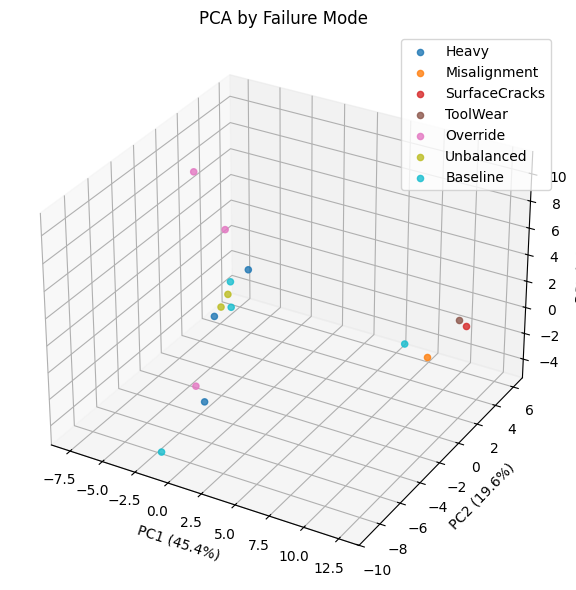

In [52]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

modes = pca_df["failure_mode"].unique().to_list()
cmap = cm.get_cmap("tab10", len(modes))
color_map = {m: cmap(i) for i, m in enumerate(modes)}

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

for m in modes:
    sub = pca_df.filter(pl.col("failure_mode") == m)
    ax.scatter(sub["PC1"], sub["PC2"], sub["PC3"], label=m, color=color_map[m], alpha=0.8)

ax.set_xlabel("PC1 (45.4%)")
ax.set_ylabel("PC2 (19.6%)")
ax.set_zlabel("PC3 (10.8%)")
ax.legend()
plt.title("PCA by Failure Mode")
plt.tight_layout()
plt.show()

In [35]:
feature_cols = df.columns[1:-1]

In [36]:
feature_cols

['SpindleAccX_mean',
 'SpindleAccX_std',
 'SpindleAccX_rms',
 'SpindleAccX_kurtosis',
 'SpindleAccX_skewness',
 'SpindleAccX_peak_to_peak',
 'SpindleAccX_crest_factor',
 'SpindleAccX_shape_factor',
 'SpindleAccX_impulse_factor',
 'SpindleAccX_margin_factor',
 'SpindleAccX_energy',
 'SpindleAccX_spectral_kurtosis_mean',
 'SpindleAccX_spectral_kurtosis_std',
 'SpindleAccX_spectral_kurtosis_skewness',
 'SpindleAccX_spectral_kurtosis_kurtosis',
 'SpindleAccY_mean',
 'SpindleAccY_std',
 'SpindleAccY_rms',
 'SpindleAccY_kurtosis',
 'SpindleAccY_skewness',
 'SpindleAccY_peak_to_peak',
 'SpindleAccY_crest_factor',
 'SpindleAccY_shape_factor',
 'SpindleAccY_impulse_factor',
 'SpindleAccY_margin_factor',
 'SpindleAccY_energy',
 'SpindleAccY_spectral_kurtosis_mean',
 'SpindleAccY_spectral_kurtosis_std',
 'SpindleAccY_spectral_kurtosis_skewness',
 'SpindleAccY_spectral_kurtosis_kurtosis',
 'SpindleAccZ_mean',
 'SpindleAccZ_std',
 'SpindleAccZ_rms',
 'SpindleAccZ_kurtosis',
 'SpindleAccZ_skewness',

In [37]:
X = df.select(feature_cols).to_numpy()

In [38]:
X

array([[ 2.31720037e-02,  2.42879039e-01,  2.43981903e-01, ...,
        -1.00611452e-01,  5.85421322e-01,  2.39375404e+00],
       [-2.77322027e-02,  6.91068426e-01,  6.91624642e-01, ...,
         4.18100190e-02,  7.18218071e-01,  1.31911862e+01],
       [-2.46966884e-02,  2.53372389e-01,  2.54573160e-01, ...,
         2.16754933e-01,  7.54900752e-01,  6.16618088e+00],
       ...,
       [ 2.78839827e-02,  2.25546600e-01,  2.27263691e-01, ...,
         1.26106518e-01,  7.67745959e-01,  4.37965325e+00],
       [ 2.42978363e-02,  2.11899938e-01,  2.13288463e-01, ...,
        -3.94029030e-03,  9.17434683e-01,  1.28469408e+01],
       [-2.66922360e-02,  1.18629720e+00,  1.18659746e+00, ...,
         2.73136423e-02,  7.21444210e-01,  1.56729593e+01]],
      shape=(15, 104))

In [39]:
X_scaled = StandardScaler().fit_transform(X)

In [40]:
pca = PCA(n_components=3)
components = pca.fit_transform(X_scaled)

In [41]:
pca_df = df.with_columns([
    pl.Series("PC1", components[:, 0]),
    pl.Series("PC2", components[:, 1]),
    pl.Series("PC3", components[:, 2]),
])

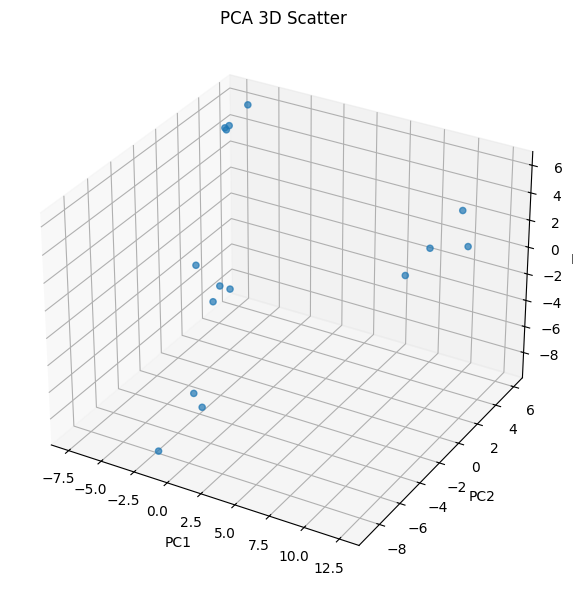

In [42]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(pca_df["PC1"], pca_df["PC2"], pca_df["PC3"], alpha=0.7)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("PCA 3D Scatter")
plt.tight_layout()
plt.show()